In [1]:
%pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 5.3 MB/s eta 0:00:00


# Análise de Eficácia de Tratamento para Ansiedade

## Objetivo da Análise

Este notebook tem como objetivo analisar a eficácia de um tratamento para ansiedade, comparando os níveis de escore de um grupo de pacientes em três momentos distintos: no início do tratamento, após 3 meses e após 6 meses. A análise estatística principal será a Análise de Variância (ANOVA) de Medidas Repetidas, complementada por testes post-hoc para identificar diferenças significativas entre os pares de momentos.

## Etapas da Análise

O notebook abordará as seguintes etapas:

1.  **Carregamento e Preparação dos Dados:** Carregar os dados e transformá-los para o formato adequado para a análise (formato 'long').
2.  **Análise Exploratória dos Dados (EDA):** Realizar uma análise descritiva dos dados e visualizar a evolução dos escores de ansiedade ao longo do tempo.
3.  **Cálculo da ANOVA de Medidas Repetidas:** Executar a ANOVA para determinar se há um efeito significativo do tempo no nível de ansiedade.
4.  **Testes Post-Hoc:** Se a ANOVA for significativa, realizar testes post-hoc para identificar quais pares de momentos apresentam diferenças estatisticamente significativas.
5.  **Conclusões:** Interpretar os resultados da ANOVA e dos testes post-hoc e apresentar as conclusões da análise.

### Importa as bibliotecas necessárias paa análise

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns

### Carregando dados

In [3]:
file_path = '/content/ansiedade_data.csv'
df = pd.read_csv(file_path)

In [4]:
print(df.shape)
df.head()

(12, 4)


,Paciente,inicio,3meses,6meses
0,Paciente 1,31,21,14
1,Paciente 2,29,21,17
2,Paciente 3,32,22,14
3,Paciente 4,28,20,11
4,Paciente 5,28,19,9


In [5]:
# Transformando o DataFrame 'df' para o formato 'long'
# Usando as colunas 'Paciente', 'inicio', '3meses', '6meses'
data_long = pd.melt(df,
                            id_vars=['Paciente'],
                            value_vars=['inicio', '3meses', '6meses'],
                            var_name='Tempo',
                            value_name='Escore_Ansiedade')

# Convertendo a coluna 'Tempo' para o tipo categórico ordenado
data_long['Tempo'] = pd.Categorical(data_long['Tempo'],
                                            categories=['inicio', '3meses', '6meses'],
                                            ordered=True)

In [6]:
data_long.head()

,Paciente,Tempo,Escore_Ansiedade
0,Paciente 1,inicio,31
1,Paciente 2,inicio,29
2,Paciente 3,inicio,32
3,Paciente 4,inicio,28
4,Paciente 5,inicio,28


### === Passo 1: Análise Descritiva ===

In [7]:
print("=== Análise Descritiva ===")
desc_stats_ansiedade = data_long.groupby('Tempo')['Escore_Ansiedade'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
desc_stats_ansiedade

=== Análise Descritiva ===


/tmp/ipython-input-926543746.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  desc_stats_ansiedade = data_long.groupby('Tempo')['Escore_Ansiedade'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])


,count,mean,median,std,min,max
Tempo,,,,,,
inicio,12,30.250000,31.0,1.602555,28,32
3meses,12,21.583333,21.5,2.391589,18,26
6meses,12,14.083333,14.0,2.778434,9,18


### === Passo 2: EDA (Análise Exploratória de Dados) ===

=== Gráfico de Análise Exploratória (Média e Erro Padrão) ===


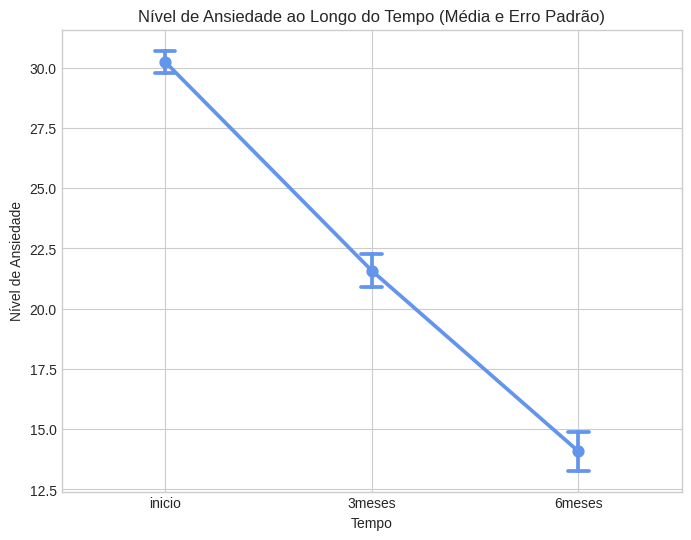

In [8]:
print("=== Gráfico de Análise Exploratória (Média e Erro Padrão) ===")
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 6))

# Gráfico de Linha com Média e Erro Padrão
sns.pointplot(
    data=data_long,
    x='Tempo',
    y='Escore_Ansiedade',
    errorbar='se',
    capsize=0.1,
    color='cornflowerblue'
)
plt.title('Nível de Ansiedade ao Longo do Tempo (Média e Erro Padrão)')
plt.ylabel('Nível de Ansiedade')
plt.xlabel('Tempo')
plt.grid(True)
plt.show()

print("\n")

### === Passo 3: ANOVA de Medidas Repetidas com statsmodels ===

In [9]:
from statsmodels.stats.anova import AnovaRM
print("=== ANOVA de Medidas Repetidas (AnovaRM) ===")

# Usando o DataFrame df_long_ansiedade e os nomes de colunas corretos
aov_stats = AnovaRM(
    data=data_long,
    depvar='Escore_Ansiedade',  # Variável dependente
    subject='Paciente',       # Coluna que identifica os sujeitos
    within=['Tempo'],         # Variável "within-subject" (medidas repetidas)
    aggregate_func='mean'     # Função de agregação, se necessário (geralmente 'mean' para RM ANOVA)
)

model_results = aov_stats.fit()
print(model_results)
print("\n")

=== ANOVA de Medidas Repetidas (AnovaRM) ===
               Anova
      F Value  Num DF  Den DF Pr > F
------------------------------------
Tempo 407.1152 2.0000 22.0000 0.0000





O teste de ANOVA de Medidas Repetidas revelou um efeito estatisticamente significativo do tempo nos níveis de escore de ansiedade [F(2, 22) = 407.12, p < 0.001].

Isso significa que há uma diferença significativa nos escores médios de ansiedade observados nos três momentos distintos (Início, 3 meses e 6 meses). Em outras palavras, o tratamento teve um impacto significativo na mudança dos níveis de ansiedade ao longo do tempo.

In [12]:
import pingouin as pg # Inclui diretamente na saída o teste de esfericidade de Mauchly

print("=== ANOVA de Medidas Repetidas (Pingouin) com Teste de Esfericidade ===")

# Usando o DataFrame df_long_ansiedade
aov_pingouin = pg.rm_anova(
    data=data_long,
    dv='Escore_Ansiedade',  # Variável dependente
    within='Tempo',         # Variável "within-subject" (medidas repetidas)
    subject='Paciente',       # Coluna que identifica os sujeitos
    detailed=True,          # Incluir detalhes, como o teste de esfericidade
    effsize='np2'           # Incluir tamanho do efeito (eta-quadrado parcial)
)

display(aov_pingouin)
print("\n")

=== ANOVA de Medidas Repetidas (Pingouin) com Teste de Esfericidade ===


,Source,SS,DF,MS,F,p-unc,np2,eps
0,Tempo,1570.888889,2,785.444444,407.115183,4.178921e-18,0.973691,0.881013
1,Error,42.444444,22,1.929293,NaN,NaN,NaN,NaN


Considerações sobre a Violação da Esfericidade:
 Quando a suposição de esfericidade é violada, o p-valor da ANOVA pode ser inflado, levando a um aumento na chance de um erro Tipo I (rejeitar a hipótese nula quando ela é verdadeira).

  Felizmente, a biblioteca pingouin (e outras como statsmodels) aplica automaticamente correções para lidar com essa violação.
  
  As correções mais comuns é a de Greenhouse-Geisser.
  
  A coluna 'eps' fornece o valor do epsilon de Greenhouse-Geisser, que é usado para ajustar os graus de liberdade da ANOVA e calcular um p-valor corrigido (que geralmente seria mostrado em uma coluna como 'p-GG' ou 'p-HF' se a violação fosse mais severa e a correção fosse aplicada explicitamente no output).
  
  No entanto, com um epsilon de 0.88, a correção de Greenhouse-Geisser é relativamente pequena e o p-valor da ANOVA ainda seria altamente significativo mesmo após a correção.

## === Passo 4: Testes Post-Hoc Tukey ===

In [13]:
print("=== Testes Post-Hoc de Tukey ===")

posthoc_tukey = pairwise_tukeyhsd(
    endog=data_long['Escore_Ansiedade'],
    groups=data_long['Tempo'],
    alpha=0.05
)

print(posthoc_tukey)
print("\n")

=== Testes Post-Hoc de Tukey ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
3meses 6meses     -7.5   0.0  -9.814  -5.186   True
3meses inicio   8.6667   0.0  6.3527 10.9807   True
6meses inicio  16.1667   0.0 13.8527 18.4807   True
---------------------------------------------------




Conclusões do teste pós-hoc Tukey:

3 Meses vs 6 Meses: A diferença média nos escores de ansiedade entre 3 meses e 6 meses é de -7.5. O p-valor ajustado (p-adj) é 0.0, o que é menor que o nível de significância de 0.05. A coluna reject é True.


3 Meses vs Inicio: A diferença média nos escores de ansiedade entre 3 meses e Início é de 8.6667. O p-valor ajustado (p-adj) é 0.0, o que é menor que 0.05. A coluna reject é True.

6 Meses vs Inicio: A diferença média nos escores de ansiedade entre 6 meses e Início é de 16.1667. O p-valor ajustado (p-adj) é 0.0, o que é menor que 0.05. A coluna reject é True.

Os testes post-hoc de Tukey indicam que há diferenças estatisticamente significativas nos escores médios de ansiedade entre todos os pares de momentos comparados (Início vs 3 meses, Início vs 6 meses, e 3 meses vs 6 meses). A direção das diferenças mostra uma redução contínua nos escores de ansiedade do Início para 3 meses e de 3 meses para 6 meses.C

## Fim da análise